# Lab 4: K-Nearest Neighbours (KNN) Classification
### Breast Cancer Dataset and Comparison with Regression Evaluation Metrics

## Task 1: Data Preparation
Load dataset, check structure, and apply feature scaling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target # 0: Malignant, 1: Benign

# Check structure, missing values, duplicates
print('Shape:', df.shape)
print('Missing Values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())

# Feature scaling
X = df.drop(columns=['target'])
y = df['target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Data Scaled using StandardScaler.')

Shape: (569, 31)
Missing Values: 0
Duplicates: 0
Data Scaled using StandardScaler.


**Importance of Feature Scaling:** KNN is a distance-based algorithm. If features are on different scales (e.g., one ranges 0-1 and another 0-1000), the feature with the larger range will dominate the distance computation. StandardScaler ensures all features contribute equally.

## Task 2: Train-Test Split Analysis
Compare performance across 80:20, 70:30, and 90:10 splits.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

splits = [0.2, 0.3, 0.1]
split_names = ['80:20', '70:30', '90:10']

for test_size, name in zip(splits, split_names):
    X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=test_size, random_state=42)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, knn.predict(X_te))
    print(f'Split {name} - Accuracy: {acc:.4f}')


Split 80:20 - Accuracy: 0.9474
Split 70:30 - Accuracy: 0.9591
Split 90:10 - Accuracy: 0.9298


**Analysis:** Changing the train-test split affects model stability. A smaller training set might underfit, while a smaller test set leads to higher variance in evaluation metrics. An 80:20 split is generally a solid balance for stability and generalization.

## Task 3: KNN Model with Heuristic K Selection
Compute initial K using heuristic rule (K = √n). Plot accuracy for nearby K values.

Heuristic K (sqrt(n)): 21


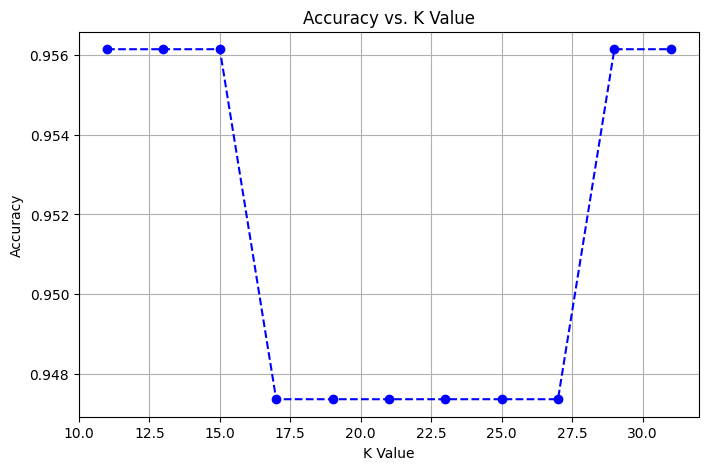

In [4]:
import math

# 80:20 split for remaining tasks
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

n_train = X_train.shape[0]
heuristic_k = math.floor(math.sqrt(n_train))
if heuristic_k % 2 == 0: heuristic_k -= 1 # Ensure odd K for binary classification
print(f'Heuristic K (sqrt(n)): {heuristic_k}')

k_values = range(max(1, heuristic_k - 10), heuristic_k + 11, 2)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, knn.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed', color='b')
plt.title('Accuracy vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

### Distance Metrics
- **Euclidean Distance:** Shortest straight-line distance between two points. Suitable for continuous numerical data without high dimensions.
- **Manhattan Distance:** Sum of absolute differences across all dimensions. Suitable for high-dimensional data or grid-like paths.

### Decision Boundary Visualization (using top 2 PCA components)

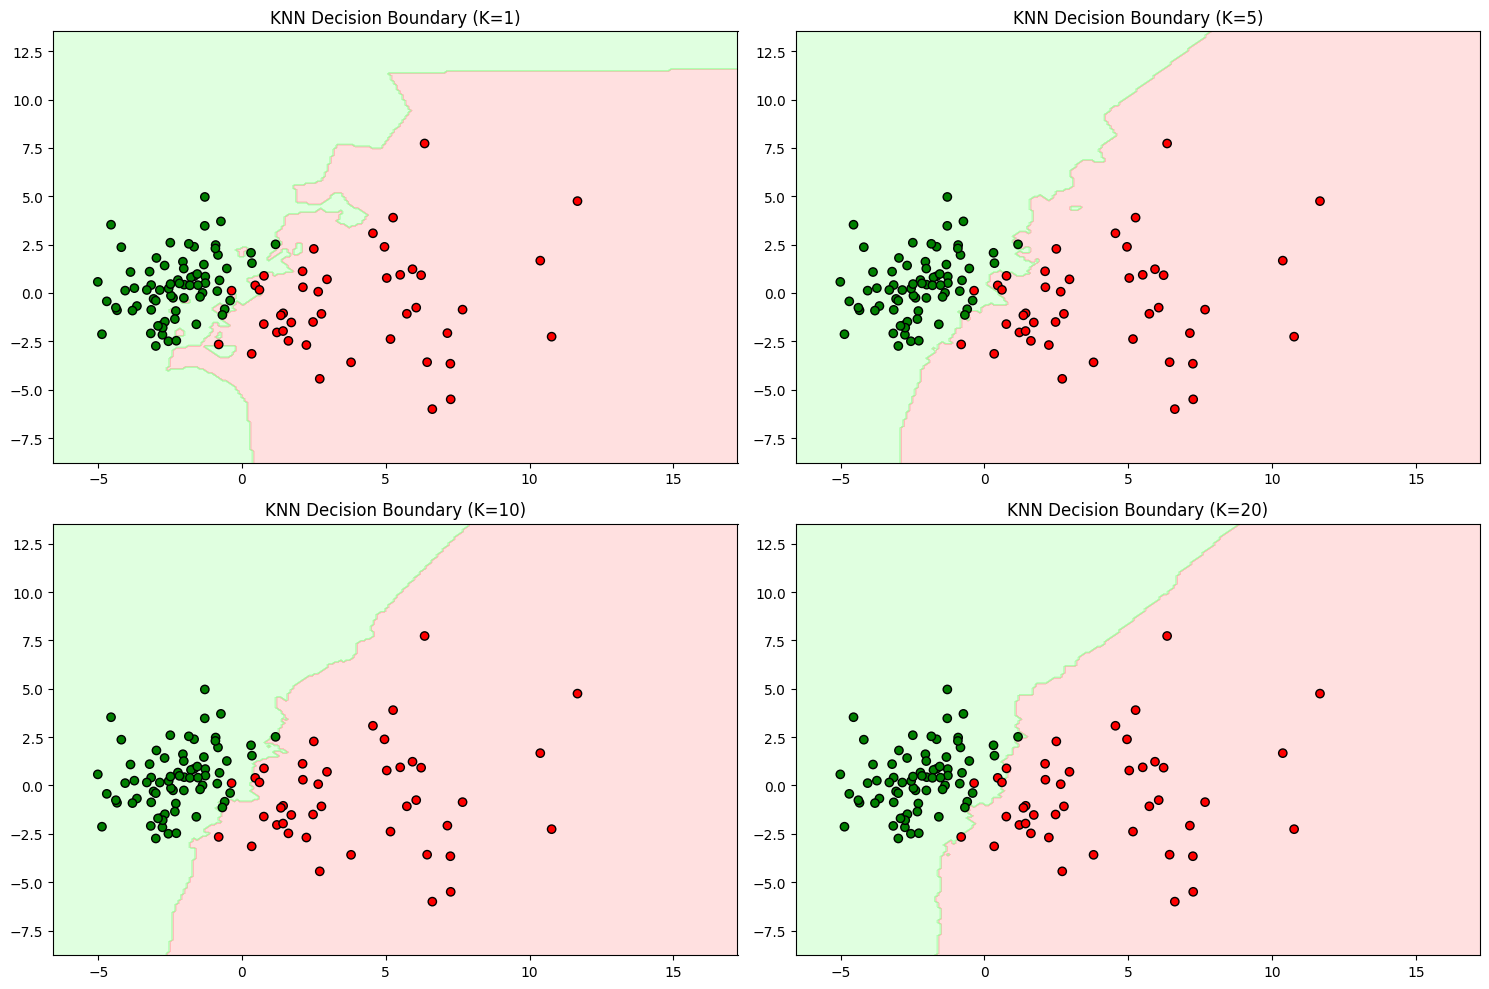

In [5]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# Reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_tr_pca, X_te_pca, y_tr_pca, y_te_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

def plot_decision_boundary(k):
    knn_pca = KNeighborsClassifier(n_neighbors=k)
    knn_pca.fit(X_tr_pca, y_tr_pca)
    
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    
    Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FF9999', '#99FF99']))
    plt.scatter(X_te_pca[:, 0], X_te_pca[:, 1], c=y_te_pca, edgecolor='k', cmap=ListedColormap(['red', 'green']))
    plt.title(f'KNN Decision Boundary (K={k})')

plt.figure(figsize=(15, 10))
for i, k in enumerate([1, 5, 10, 20]):
    plt.subplot(2, 2, i+1)
    plot_decision_boundary(k)
plt.tight_layout()
plt.show()

**Analysis:** Small K (K=1) leads to highly complex decision boundaries (overfitting and sensitive to noise). As K increases, the boundary becomes smoother and more generalized.

## Task 4: Cross Validation

Optimal K from Cross-Validation: 13


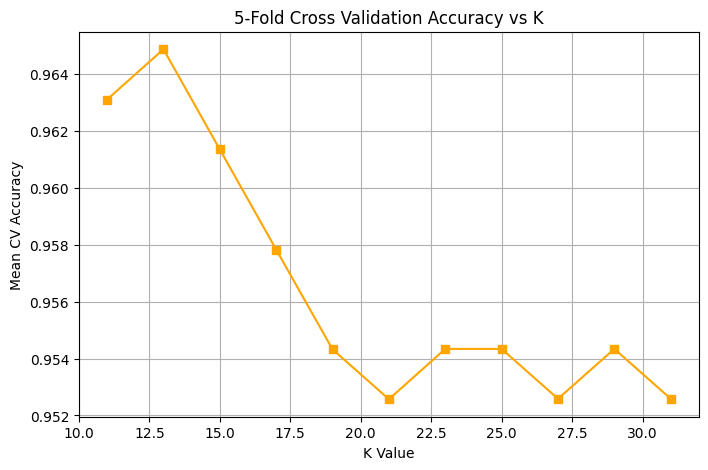

In [6]:
from sklearn.model_selection import cross_val_score

cv_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=5) # 5-Fold CV
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f'Optimal K from Cross-Validation: {optimal_k}')

plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_scores, marker='s', color='orange')
plt.title('5-Fold Cross Validation Accuracy vs K')
plt.xlabel('K Value')
plt.ylabel('Mean CV Accuracy')
plt.grid()
plt.show()

## Task 5: Classification Evaluation

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



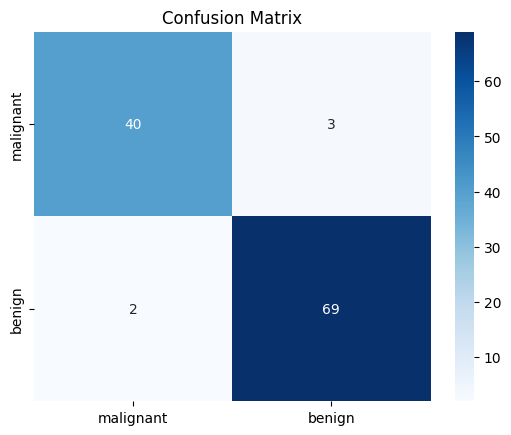

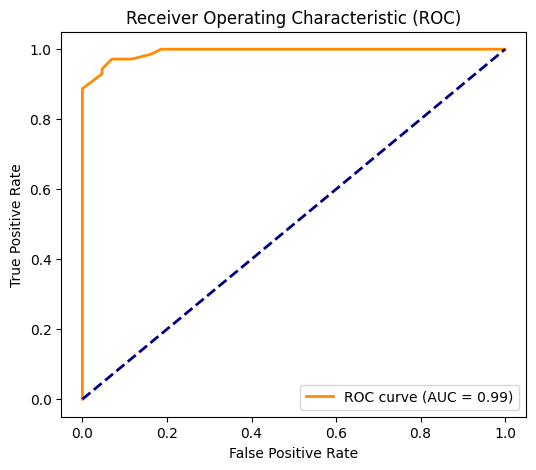

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train, y_train)
y_pred = final_knn.predict(X_test)
y_prob = final_knn.predict_proba(X_test)[:, 1]

print('Classification Report:\n', classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Confusion Matrix')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

## Task 6: Comparative Study with Regression (Lab 3 Integration)

### Differences Between Evaluation Metrics:
- **Error-based evaluation (Regression):** Measures continuous distances/differences between actual and predicted values (e.g., RMSE, MAE). The goal is to minimize magnitude of error.
- **Decision-based evaluation (Classification):** Measures discrete correctness (right vs. wrong class). Metrics like Precision and Recall care about categorical outcomes.

### Metric Comparisons:
- **R² Score vs Accuracy:** R² measures how much variance is explained by a regression model. Accuracy measures the percentage of correctly predicted classes.
- **RMSE vs F1 Score:** RMSE penalizes large numerical errors in prediction. F1 Score balances Precision and Recall, crucial for imbalanced classification.
- **MAE vs Confusion Matrix:** MAE gives average absolute error distance. A Confusion Matrix gives a detailed breakdown of exact misclassifications (False Positives vs False Negatives).

### Inference Requirement (Healthcare Analytics):
- **Regression Metrics:** Measure the magnitude of continuous predictions (e.g., tumor size prediction).
- **Classification Metrics:** Measure decision correctness (e.g., Benign vs Malignant).
- **Why is accuracy insufficient?** In medical diagnosis, data is often imbalanced. A model predicting everyone as "Benign" might have 90% accuracy but miss all cancer cases.
- **Why are recall and ROC-AUC more relevant?** Recall minimizes False Negatives (missing a cancer diagnosis is deadly). ROC-AUC evaluates the model's ability to distinguish between classes across different thresholds.

## Task 7: Analytical Questions

1. **Why is KNN called a lazy learning algorithm?** It does not build an explicit model during the training phase. It simply stores the training dataset and performs all distance computations during the prediction phase.
2. **Why is feature scaling required in KNN?** KNN uses distance metrics (like Euclidean). Unscaled features with larger ranges will disproportionately influence the distance calculation.
3. **Explain heuristic K selection using √n rule:** Setting K equal to the square root of the number of training samples (and making it odd) provides a statistically sound baseline that balances complexity and smoothing.
4. **Why is cross-validation more reliable than a single train-test split?** It trains and evaluates the model on multiple different subsets, ensuring the performance metrics are not just dependent on one "lucky" or "unlucky" random split.
5. **How does K affect bias-variance trade-off?** Small K = Low Bias, High Variance (Overfitting). Large K = High Bias, Low Variance (Underfitting).
6. **Why is recall more important than accuracy in cancer prediction?** Recall focuses on capturing all actual positive (Malignant) cases. A False Negative (telling a sick patient they are healthy) is much worse than a False Positive.
7. **What is the limitation of very large K values?** If K is too large, it considers points that are too far away, and the prediction will just default to the majority class in the entire dataset (underfitting).

## Conclusion
- **Optimal K:** Selected through both the heuristic baseline ($\sqrt{n}$) and validated through K-Fold Cross Validation.
- **Train-Test Splits:** Showcased that smaller training sets cause variability, and 80:20 provides a stable evaluation.
- **Performance:** The model performs highly effectively on the Breast Cancer dataset, with a focus on Recall and ROC-AUC for medical reliability.
- **Regression vs Classification:** Lab 3 metrics aimed to minimize continuous error, while Lab 4 metrics optimize class decision boundaries and correct categorization.